In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import f1_score , confusion_matrix , classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
x = df.drop(columns = ["Revenue"])
y = df["Revenue"].astype(int)

In [6]:
num_features = x.select_dtypes(include = ["int64" , "float64"]).columns
cat_features = x.select_dtypes(include = ["object"]).columns

In [7]:
print(num_features)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')


In [8]:
print(cat_features)

Index(['Month', 'VisitorType'], dtype='object')


In [9]:
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num" , StandardScaler() , num_features),
        ("cat" , OneHotEncoder(handle_unknown="ignore") , cat_features)
    ]
)

In [11]:
DT = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)

In [12]:
pipe = Pipeline(
    steps=[
        ("preprocess" , preprocessor),
        ("model" , DT)
    ]
)

In [13]:
pipe.fit(x_train , y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred = pipe.predict(x_test)

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6278381046396841

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      2084
           1       0.50      0.83      0.63       382

    accuracy                           0.85      2466
   macro avg       0.73      0.84      0.77      2466
weighted avg       0.89      0.85      0.86      2466


Confusion Matrix:
 [[1771  313]
 [  64  318]]


# Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth" : [2 , 4 , 6 , 8],
    "model__min_samples_leaf" : [20 , 30 , 40 , 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [16]:
grid.fit(x_train , y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [2, 4, ...], 'model__min_samples_leaf': [20, 30, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [17]:
print("Best F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best F1: 0.6666738277119931
Best params: {'model__max_depth': 2, 'model__min_samples_leaf': 20}


# Best Decision Tree

In [27]:
best_dt = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

best_pipe = Pipeline(
    steps=[
        ("preprocess" , preprocessor),
        ("model" , best_dt)
    ]
)

best_pipe.fit(x_train , y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_pred = best_pipe.predict(x_test)

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6485310119695321

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92      2084
           1       0.55      0.78      0.65       382

    accuracy                           0.87      2466
   macro avg       0.76      0.83      0.78      2466
weighted avg       0.89      0.87      0.88      2466


Confusion Matrix:
 [[1845  239]
 [  84  298]]


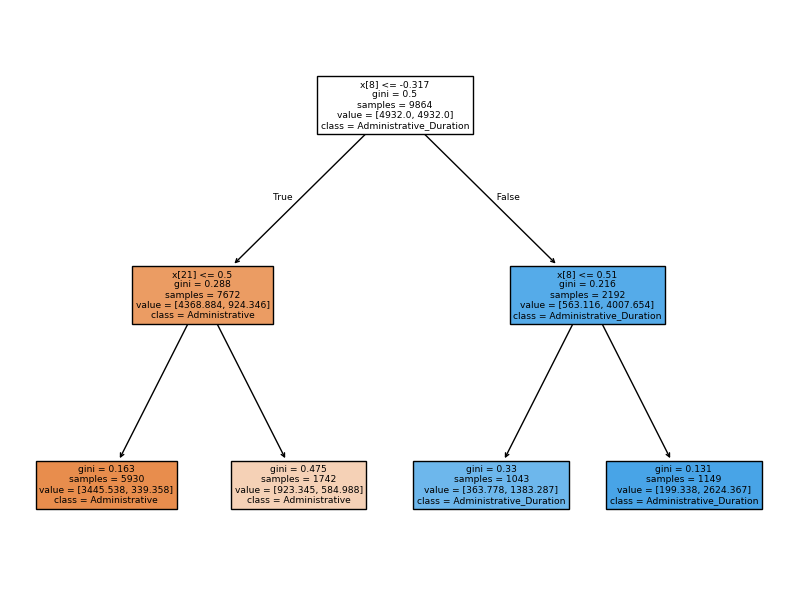

In [29]:
plt.figure(figsize=(8 , 6))
plot_tree(best_dt , class_names=x.columns , filled=True)
plt.tight_layout()
plt.show()